In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

import json

In [4]:
df = pd.read_csv('data/YT-100K.csv', sep='\t', on_bad_lines='skip', engine='python')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81413 entries, 0 to 81412
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   video_id              81413 non-null  object
 1   comment_id            81413 non-null  object
 2   commenter_name        81413 non-null  object
 3   commenter_channel_id  81413 non-null  object
 4   comment               81406 non-null  object
 5   votes                 81413 non-null  object
 6   original_channel_id   81413 non-null  object
 7   category              81413 non-null  object
dtypes: object(8)
memory usage: 5.0+ MB


,video_id,comment_id,commenter_name,commenter_channel_id,comment,votes,original_channel_id,category
count,81413,81413,81413,81413,81406,81413,81413,81413
unique,21767,75215,80254,80273,75211,334,80273,15
top,ac12b68b0ae044327da6d17cb59beddb,7aba075adb50a589f94c87fb569882dc,4d952b101860d6014bc04959e23a786c,7cc7ddbbf75ae8aca6f46ac5207c1769,❤,0,oc_7cc7ddbbf75ae8aca6f46ac5207c1769,entertainment
freq,305,161,53,53,161,56230,53,25685


In [5]:
# Steps to clean data
df.drop_duplicates(inplace=True)
df = df.dropna(subset=['comment'])
df = df[df['category'] != 'nonprofit']
df.reset_index(drop=True, inplace=True)

# Fix data types
df['votes'] = pd.to_numeric(df['votes'], errors='coerce').fillna(0).astype(int)

# Cap votes at 99th percentile
max_votes = df['votes'].quantile(0.99)
df['votes'] = df['votes'].clip(upper=max_votes)

df['comment_length'] = df['comment'].apply(len)
max_length = df['comment_length'].quantile(0.99)
df['comment_length'] = df['comment_length'].clip(upper=max_length)

# Comments per video and per channel
comments_per_video = df['video_id'].value_counts().to_dict()
df['comments_per_video'] = df['video_id'].map(comments_per_video)

comments_per_channel = df['commenter_channel_id'].value_counts().to_dict()
df['comments_per_channel'] = df['commenter_channel_id'].map(comments_per_channel)

# Category count
category_counts = df['category'].value_counts().to_dict()
df['category_count'] = df['category'].map(category_counts)

# Convert category to categorical type
df['category'] = df['category'].astype('category')

df['category'] = df['category'].str.strip().str.lower()
df['category'] = df['category'].astype('category')

df.to_csv("data/YT-100K_cleaned.csv", index=False)

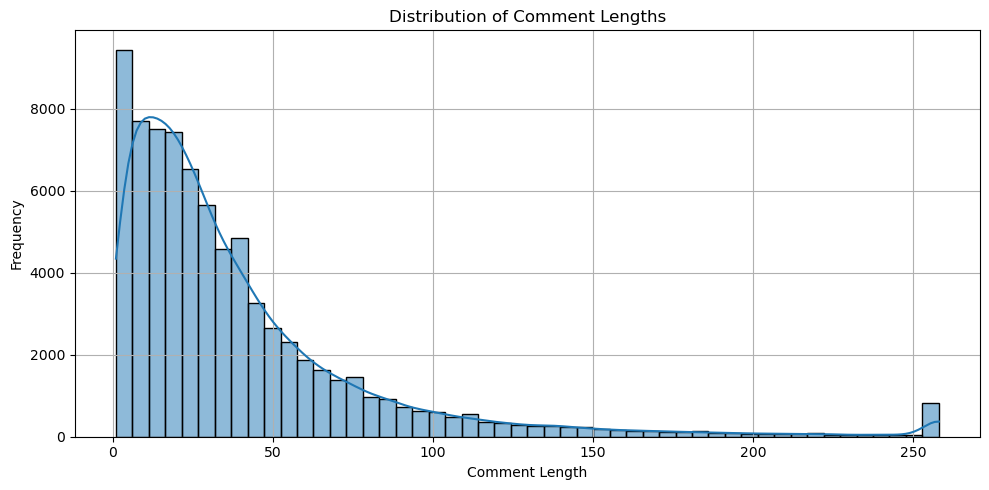

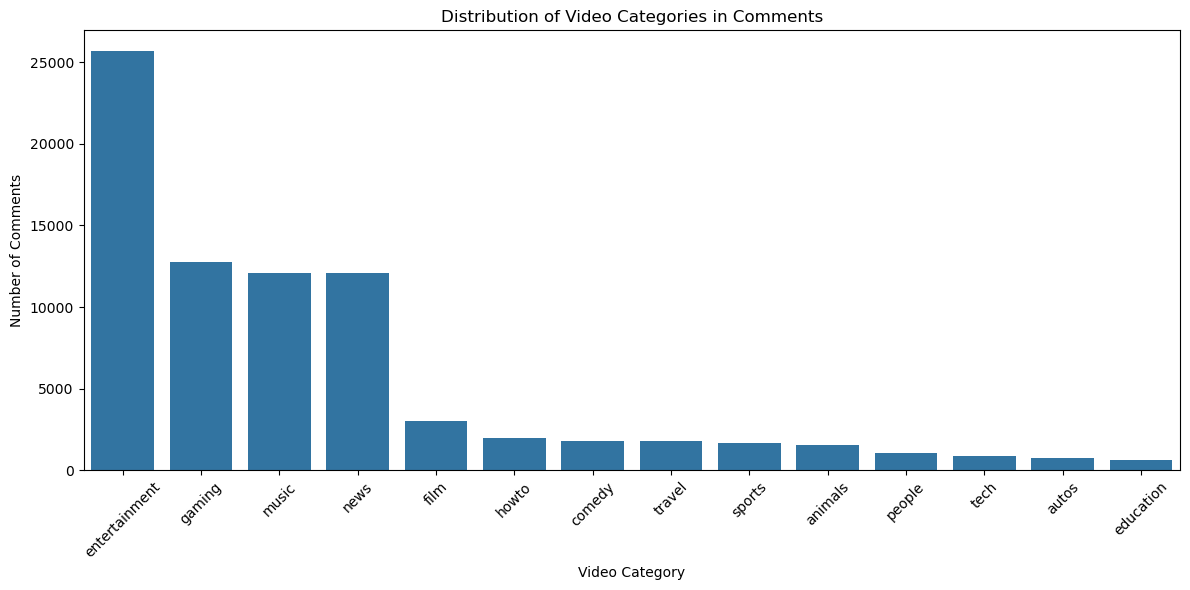

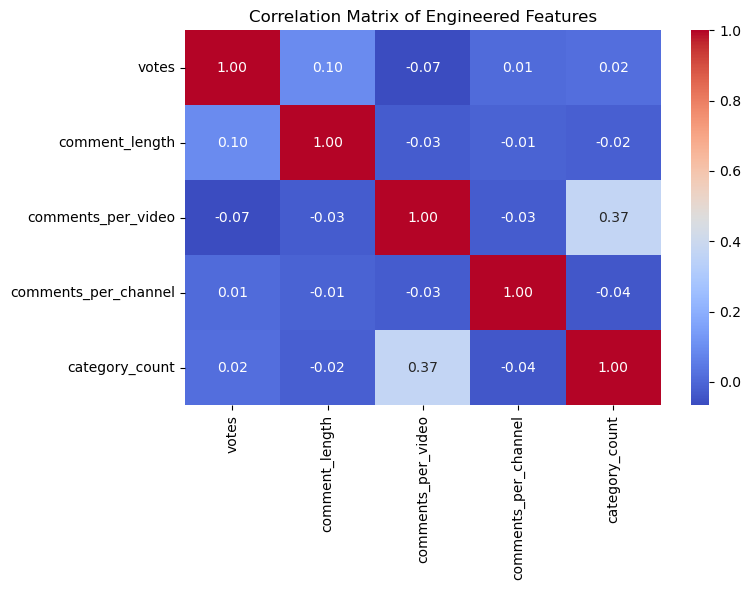

In [6]:
# Distribution of comment lengths
plt.figure(figsize=(10, 5))
sns.histplot(df['comment_length'], bins=50, kde=True)
plt.title("Distribution of Comment Lengths")
plt.xlabel("Comment Length")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='category', order=df['category'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribution of Video Categories in Comments')
plt.xlabel('Video Category')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()

# Correlation matrix
numeric_cols = ['votes', 'comment_length', 'comments_per_video', 'comments_per_channel', 'category_count']
correlation = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Engineered Features")
plt.tight_layout()
plt.show()

In [7]:
# Determine each user's most frequent (majority) category
user_majority_category = df.groupby('commenter_channel_id')['category'] \
                           .agg(lambda x: x.value_counts().idxmax())

# Map that majority category back to the dataframe
df['majority_category'] = df['commenter_channel_id'].map(user_majority_category)

# Create a new column: 1 if category == majority_category, else 0
df['in_majority_genre'] = (df['category'] == df['majority_category']).astype(int)

# Create a pivot table for cross-genre interaction rates
interaction_matrix = pd.crosstab(df['majority_category'], df['category'], normalize='index')

# Limit to top genres for readability
top_categories = df['category'].value_counts().nlargest(10).index
interaction_matrix = interaction_matrix.loc[top_categories, top_categories]

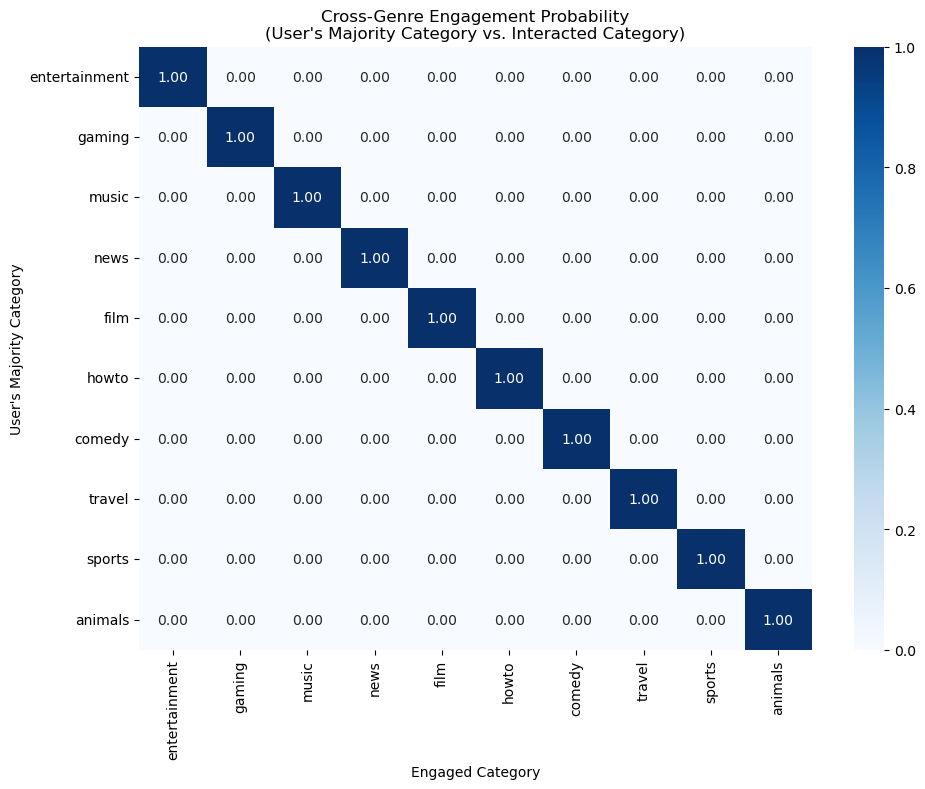

In [8]:
# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(interaction_matrix, cmap='Blues', annot=True, fmt=".2f")
plt.title("Cross-Genre Engagement Probability\n(User's Majority Category vs. Interacted Category)")
plt.xlabel("Engaged Category")
plt.ylabel("User's Majority Category")
plt.tight_layout()
plt.show()

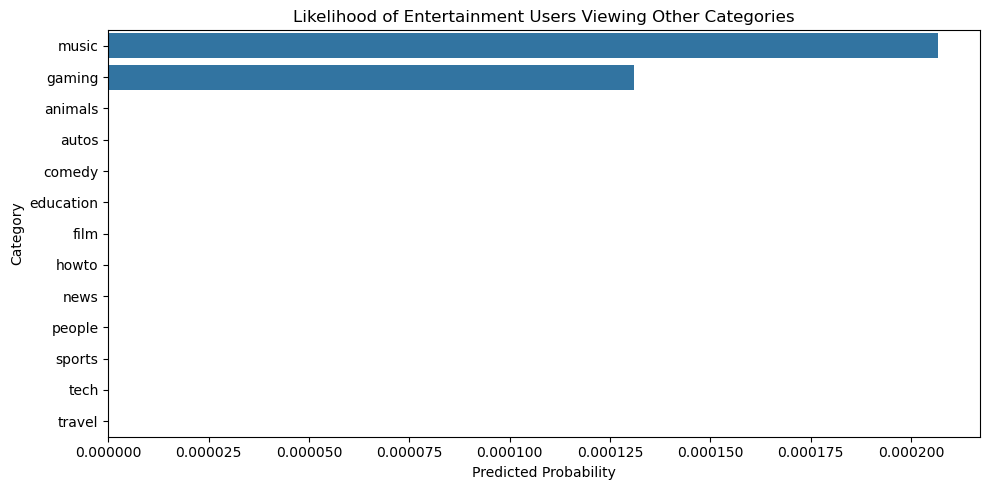

In [9]:
# Build full user-genre matrix across all users
user_genre_matrix_full = pd.crosstab(df['commenter_channel_id'], df['category'])

# Determine majority category for each user
user_majority_genre = df.groupby('commenter_channel_id')['category'] \
                        .agg(lambda x: x.value_counts().idxmax()) \
                        .rename('majority_category')

# Filter users whose majority category is 'entertainment'
entertainment_users = user_majority_genre[user_majority_genre == 'entertainment'].index
user_genre_matrix_ent = user_genre_matrix_full.loc[entertainment_users]

# Prepare predictions for all categories except 'entertainment'
if 'entertainment' in user_genre_matrix_ent.columns:
    user_genre_matrix_ent = user_genre_matrix_ent.drop(columns='entertainment')

predicted_probs = {}

for genre in user_genre_matrix_ent.columns:
    X = user_genre_matrix_ent.drop(columns=genre)
    y = user_genre_matrix_ent[genre]

    if y.nunique() < 2:
        # Skip genres with no positive samples in this group
        predicted_probs[genre] = 0
        continue

    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)

    y_proba = clf.predict_proba(X_test)[:, 1]
    predicted_probs[genre] = y_proba.mean()

# Plot results
prediction_df = pd.DataFrame({
    'Genre': list(predicted_probs.keys()),
    'Predicted Likelihood': list(predicted_probs.values())
}).sort_values(by='Predicted Likelihood', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Predicted Likelihood', y='Genre', data=prediction_df)
plt.title('Likelihood of Entertainment Users Viewing Other Categories')
plt.xlabel('Predicted Probability')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [10]:
# Load the dataset
df_us = pd.read_csv('data/US_youtube_trending_data.csv')
df_us.head()
df_us.info()
df_us.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268787 entries, 0 to 268786
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   video_id           268787 non-null  object
 1   title              268787 non-null  object
 2   publishedAt        268787 non-null  object
 3   channelId          268787 non-null  object
 4   channelTitle       268787 non-null  object
 5   categoryId         268787 non-null  int64 
 6   trending_date      268787 non-null  object
 7   tags               268787 non-null  object
 8   view_count         268787 non-null  int64 
 9   likes              268787 non-null  int64 
 10  dislikes           268787 non-null  int64 
 11  comment_count      268787 non-null  int64 
 12  thumbnail_link     268787 non-null  object
 13  comments_disabled  268787 non-null  bool  
 14  ratings_disabled   268787 non-null  bool  
 15  description        264238 non-null  object
dtypes: bool(2), int64(5)

,categoryId,view_count,likes,dislikes,comment_count
count,268787.000000,2.687870e+05,2.687870e+05,268787.000000,2.687870e+05
mean,18.743511,2.734467e+06,1.314697e+05,1134.277495,1.014303e+04
std,6.786562,9.794087e+06,4.539469e+05,8047.291315,7.260853e+04
min,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
25%,17.000000,4.725410e+05,1.796300e+04,0.000000,1.280000e+03
50%,20.000000,9.368710e+05,4.020500e+04,0.000000,2.754000e+03
75%,24.000000,2.106178e+06,9.877300e+04,467.000000,6.386000e+03
max,29.000000,1.407644e+09,1.602153e+07,879354.000000,6.738537e+06


In [11]:
# Convert 'publishedAt' to datetime
df_us['publishedAt'] = pd.to_datetime(df_us['publishedAt'])

# Convert 'trending_date' to datetime
df_us['trending_date'] = pd.to_datetime(df_us['trending_date'])

# Map category_id to category names using the provided JSON file
with open('data/US_category_id.json') as f:
    categories = json.load(f)

category_mapping = {int(item['id']): item['snippet']['title'] for item in categories['items']}
df_us['category'] = df_us['categoryId'].map(category_mapping)

In [12]:
# Calculate average views, likes, and comment counts per category
engagement_metrics = df_us.groupby('category').agg({
    'view_count': 'mean',
    'likes': 'mean',
    'comment_count': 'mean'
}).reset_index()

# Rename columns for clarity
engagement_metrics.columns = ['Category', 'Average Views', 'Average Likes', 'Average Comments']

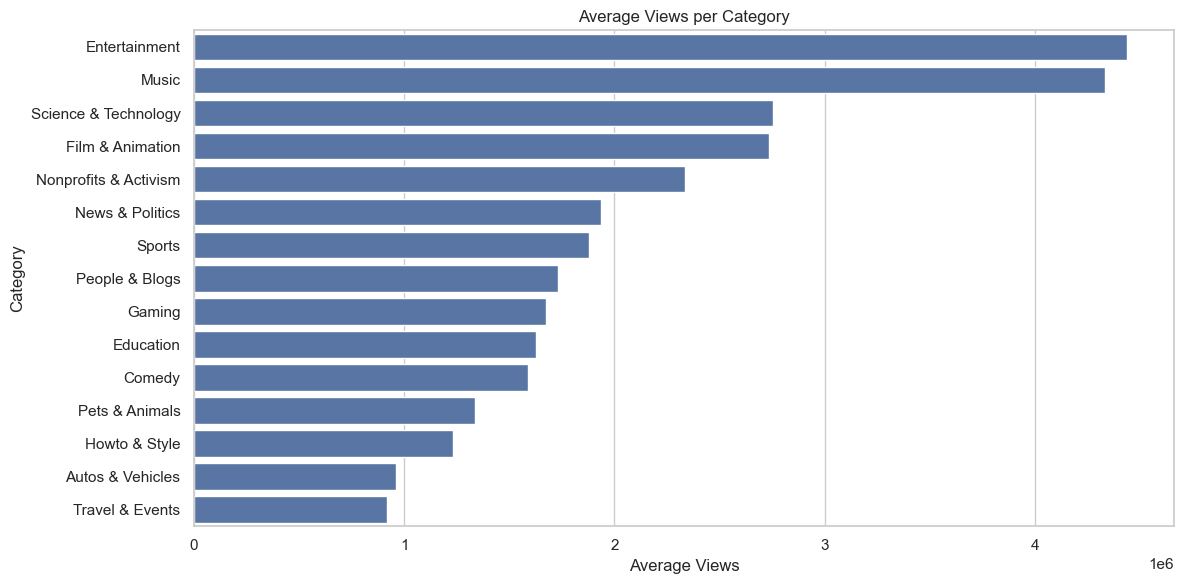

In [13]:
# Set the style
sns.set(style="whitegrid")

# Plot average views per category
plt.figure(figsize=(12, 6))
sns.barplot(x='Average Views', y='Category', data=engagement_metrics.sort_values('Average Views', ascending=False))
plt.title('Average Views per Category')
plt.xlabel('Average Views')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [14]:
# Apply 1:1 mapping
category_mapping = {
    'entertainment': 'entertainment',
    'gaming': 'gaming',
    'music': 'music',
    'news': 'news and politics',
    'film': 'film and animation',
    'howto': 'howto & style',
    'comedy': 'comedy',
    'travel': 'travel & events',
    'sports': 'sports',
    'animals': 'pets & animals',
    'people': 'people & blogs',
    'tech': 'science & technology',
    'autos': 'autos & vehicles',
    'education': 'education'
}

# Apply mapping
df['category'] = df['category'].map(category_mapping)

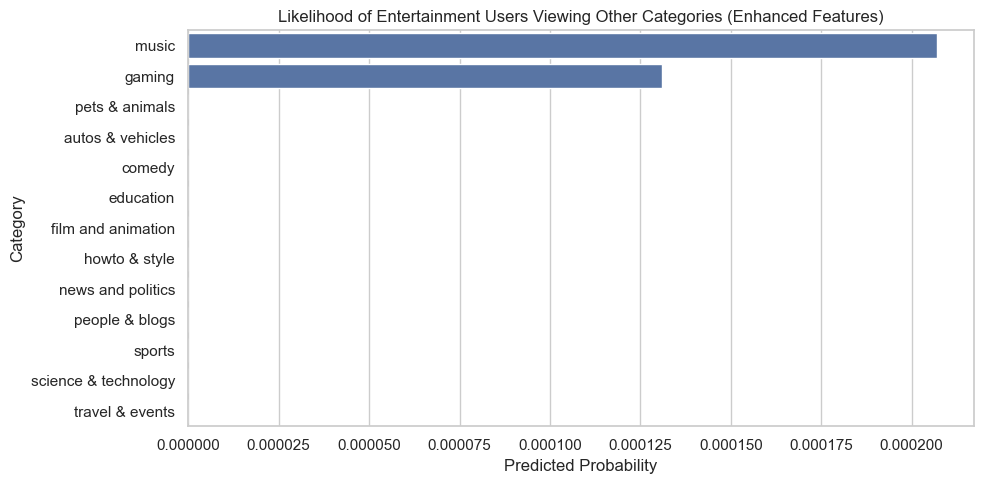

In [15]:
# Merge video-level features into the YT-100K data
merged_df = df.merge(
    df_us[['video_id', 'view_count', 'likes', 'dislikes', 'comment_count']],
    on='video_id', how='left'
)

# Fill missing video stats
merged_df[['view_count', 'likes', 'dislikes', 'comment_count']] = merged_df[['view_count', 'likes', 'dislikes', 'comment_count']].fillna(0)

# Aggregate video metrics per user
user_video_features = merged_df.groupby('commenter_channel_id')[['view_count', 'likes', 'dislikes', 'comment_count']].mean()

# Determine each user's majority genre
merged_df = merged_df.dropna(subset=['category'])
user_majority_genre = merged_df.groupby('commenter_channel_id')['category'] \
                        .agg(lambda x: x.value_counts().idxmax()) \
                        .rename('majority_category')

# Build user-category interaction matrix
user_genre_matrix_full = pd.crosstab(merged_df['commenter_channel_id'], merged_df['category'])

# Get users whose majority genre is entertainment
entertainment_users = user_majority_genre[user_majority_genre == 'entertainment'].index

# Build filtered genre matrix and feature set
user_genre_matrix_ent = user_genre_matrix_full.loc[entertainment_users]
video_feature_matrix = user_video_features.loc[entertainment_users]

# Drop the 'entertainment' column from the target matrix (we want to predict others)
if 'entertainment' in user_genre_matrix_ent.columns:
    user_genre_matrix_ent = user_genre_matrix_ent.drop(columns='entertainment')

# Train per-genre prediction models
predicted_probs = {}

for genre in user_genre_matrix_ent.columns:
    y = user_genre_matrix_ent[genre]
    X = video_feature_matrix.copy()

    class_counts = y.value_counts()
    if len(class_counts) < 2 or class_counts.min() < 2:
        predicted_probs[genre] = 0
        continue

    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)

    y_proba = clf.predict_proba(X_test)[:, 1]
    predicted_probs[genre] = y_proba.mean()

# Format results
prediction_df = pd.DataFrame({
    'Genre': list(predicted_probs.keys()),
    'Predicted Likelihood': list(predicted_probs.values())
}).sort_values(by='Predicted Likelihood', ascending=False)

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x='Predicted Likelihood', y='Genre', data=prediction_df)
plt.title('Likelihood of Entertainment Users Viewing Other Categories (Enhanced Features)')
plt.xlabel('Predicted Probability')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [16]:
# Load datasets
df = pd.read_csv("data/YT-100K_cleaned.csv")
df_us = pd.read_csv("data/US_youtube_trending_data.csv")

# Make sure both are strings (or both ints), no stray whitespace
df['video_id']   = df['video_id'].astype(str).str.strip()
df_us['video_id'] = df_us['video_id'].astype(str).str.strip()

merged = df.merge(
    df_us[['video_id','view_count','likes','dislikes','comment_count']],
    on='video_id',
    how='left',
    indicator=True
)

# how many comments have no matching trending row?
missing_pct = (merged['_merge'] == 'left_only').mean() * 100
print(f"{missing_pct:.1f}% of comment rows had no trending data")

100.0% of comment rows had no trending data


In [17]:
# Load datasets
df = pd.read_csv("data/YT-100K_cleaned.csv")
df_us = pd.read_csv("data/US_youtube_trending_data.csv")

# Standardize categories
df['category'] = df['category'].str.lower().str.strip()

with open('data/US_category_id.json') as f:
    categories = json.load(f)

category_mapping = {int(item['id']): item['snippet']['title'] for item in categories['items']}
df_us['category'] = df_us['categoryId'].map(category_mapping)
df_us['category'] = df_us['category'].str.lower().str.strip()

# Drop rows without category
df = df.dropna(subset=['category'])

# Merge video stats
merged_df = df.merge(
    df_us[['video_id', 'view_count', 'likes', 'dislikes', 'comment_count']],
    on='video_id', how='left'
)

# Fill missing values
merged_df[['view_count', 'likes', 'dislikes', 'comment_count']] = merged_df[
    ['view_count', 'likes', 'dislikes', 'comment_count']
].fillna(0)

# 2) Compute per‐user genre counts
user_genre_counts = (
    merged_df
    .groupby(['commenter_channel_id', 'category'])
    .size()
    .unstack(fill_value=0)
)
all_genres = sorted(user_genre_counts.columns)

# 3) Basic engagement features (average video stats per user)
user_video_stats = merged_df.groupby('commenter_channel_id')[
    ['view_count', 'likes', 'dislikes', 'comment_count']
].mean()

# 4) Genre ratios
user_total_comments = user_genre_counts.sum(axis=1)
user_genre_ratios = (
    user_genre_counts
    .div(user_total_comments, axis=0)
    .fillna(0)
    .add_prefix("genre_ratio_")
)

# 5) Genre diversity (entropy)
def entropy(row):
    p = row[row > 0]
    return -(p * np.log2(p)).sum()
user_genre_entropy = user_genre_ratios.apply(entropy, axis=1).rename("genre_entropy")

# 6) Number of unique genres commented on
user_genre_diversity = (user_genre_counts > 0).sum(axis=1).rename("unique_genres")

# 7) Majority genre
user_majority_genre = user_genre_counts.idxmax(axis=1).rename("majority_category")

# 8) Combine all features into one DataFrame
user_features = pd.concat([
    user_video_stats,
    user_genre_ratios,
    user_genre_entropy,
    user_genre_diversity,
    user_majority_genre
], axis=1)

# 9) Filter to users whose majority_category is 'entertainment'
ent_users = user_features[user_features['majority_category'] == 'entertainment'].index

# 10) Prepare X (features) and iterate over each non-entertainment genre
feature_cols = [c for c in user_features.columns if c != 'majority_category']
X_ent = user_features.loc[ent_users, feature_cols]

predicted_probs = {}
for genre in all_genres:
    if genre == 'entertainment':
        continue

    y = (user_genre_counts.loc[ent_users, genre] > 0).astype(int)

    # BEFORE training, check both:
    vc = y.value_counts()
    # If we have fewer than 2 classes *or* fewer than 2 samples in the minority class,
    # we can’t fit a logistic model—so just record 0.0 likelihood.
    if len(vc) < 2 or vc.min() < 2:
        predicted_probs[genre] = 0.0
        continue

    # otherwise we’re safe to stratify and train
    X_train, X_test, y_train, y_test = train_test_split(
        X_ent, y, stratify=y, test_size=0.2, random_state=42
    )
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)
    predicted_probs[genre] = clf.predict_proba(X_test)[:, 1].mean()

# 11) Build and display results
prediction_df = (
    pd.DataFrame.from_dict(predicted_probs, orient='index', columns=['Predicted Likelihood'])
      .reset_index()
      .rename(columns={'index': 'Genre'})
      .sort_values('Predicted Likelihood', ascending=False)
)
print(prediction_df)

        Genre  Predicted Likelihood
7       music              0.000180
5      gaming              0.000068
0     animals              0.000000
1       autos              0.000000
2      comedy              0.000000
3   education              0.000000
4        film              0.000000
6       howto              0.000000
8        news              0.000000
9      people              0.000000
10     sports              0.000000
11       tech              0.000000
12     travel              0.000000


Genre 'animals': best params = {'model__C': 0.01, 'model__penalty': 'l2'}, best CV ROC AUC = 1.000
Genre 'autos': best params = {'model__C': 0.01, 'model__penalty': 'l2'}, best CV ROC AUC = 1.000
Genre 'comedy': best params = {'model__C': 0.01, 'model__penalty': 'l2'}, best CV ROC AUC = 1.000
Genre 'education': best params = {'model__C': 0.01, 'model__penalty': 'l2'}, best CV ROC AUC = 1.000
Genre 'film': best params = {'model__C': 0.01, 'model__penalty': 'l2'}, best CV ROC AUC = 1.000
Genre 'gaming': best params = {'model__C': 0.01, 'model__penalty': 'l2'}, best CV ROC AUC = 1.000
Genre 'howto': best params = {'model__C': 0.01, 'model__penalty': 'l2'}, best CV ROC AUC = 1.000
Genre 'music': best params = {'model__C': 0.01, 'model__penalty': 'l2'}, best CV ROC AUC = 1.000
Genre 'news': best params = {'model__C': 0.01, 'model__penalty': 'l2'}, best CV ROC AUC = 1.000
Genre 'people': best params = {'model__C': 0.01, 'model__penalty': 'l2'}, best CV ROC AUC = 1.000
Genre 'sports': best pa

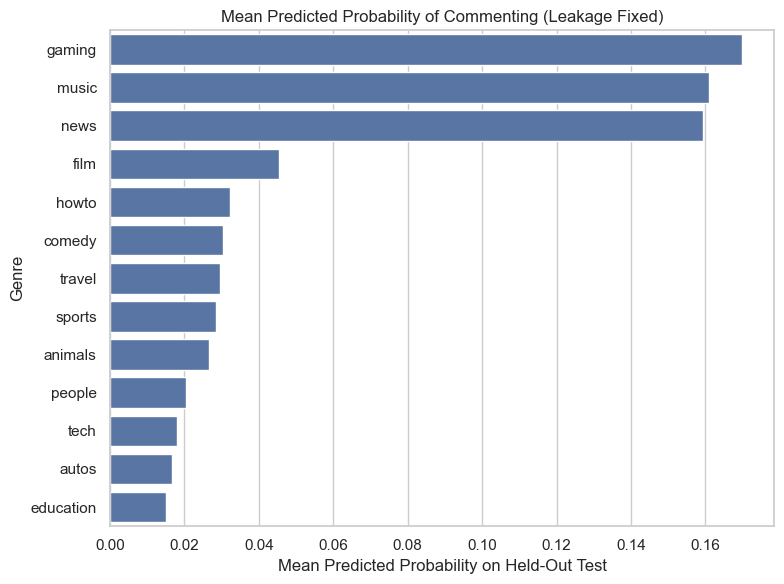

In [18]:
user_features = user_features.copy()
user_features['is_entertainment_majority'] = (
    user_features['majority_category'] == 'entertainment'
).astype(int)

# 2) Prepare feature matrix for all users:
#    We'll select columns except 'majority_category'; but in loop we'll drop genre-specific features.
base_feature_cols = [c for c in user_features.columns if c not in ['majority_category']]

# 3) Hyperparameter grid for LogisticRegression
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],  # add 'l1' if you include solver='liblinear' or 'saga'
}

predicted_probs = {}

# 4) Loop over each genre as target
for genre in all_genres:
    if genre.lower() == 'entertainment':
        continue  # skip baseline itself

    # 4a) Build binary target over all users: did the user ever comment in this genre?
    # Note: user_genre_counts[genre] gives counts per user; may raise KeyError if genre missing: use .get
    if genre not in user_genre_counts.columns:
        # no data for this genre
        predicted_probs[genre] = np.nan
        print(f"Skipping genre '{genre}' because it's not in user_genre_counts columns.")
        continue

    y_all = (user_genre_counts[genre] > 0).astype(int)
    # Align indexes:
    # If user_features index may differ, reindex y_all to user_features index, filling missing with 0:
    y_all = y_all.reindex(user_features.index, fill_value=0)

    # 4b) Check class balance
    vc = y_all.value_counts()
    n_pos = vc.get(1, 0)
    n_neg = vc.get(0, 0)
    if len(vc) < 2 or vc.min() < 5:
        print(f"Skipping genre '{genre}' due to insufficient samples (counts: {vc.to_dict()})")
        predicted_probs[genre] = np.nan
        continue

    # 4c) Build feature columns for this genre by dropping direct leakage:
    #    Drop any column that directly encodes interactions with this genre:
    #    - genre_ratio_<genre>
    #    - potentially any count_<genre> if present
    #    We look for columns starting with "genre_ratio_<genre>" or other direct indicators.
    leak_prefix = f"genre_ratio_{genre}"
    feature_cols = [
        c for c in base_feature_cols
        if not c.startswith(leak_prefix)
        # If you also had raw counts columns like "<genre>" in features, drop them similarly:
        # and not c == f"count_{genre}"
    ]
    X_all = user_features[feature_cols]
    # Now X_all aligned with y_all via index

    # 4d) Stratified train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, stratify=y_all, test_size=0.2, random_state=42
    )

    # 4e) Check that after split both classes still have >=2 samples for CV
    vc_train = y_train.value_counts()
    n_pos_tr = vc_train.get(1, 0)
    n_neg_tr = vc_train.get(0, 0)
    cv_folds = min(5, n_pos_tr, n_neg_tr)
    if cv_folds < 2:
        print(f"Skipping genre '{genre}' due to too few per-class samples after split (npos={n_pos_tr}, nneg={n_neg_tr})")
        predicted_probs[genre] = np.nan
        continue

    # 4f) Build pipeline and GridSearchCV
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, solver='liblinear'))
    ])
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    gs = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    try:
        gs.fit(X_train, y_train)
    except Exception as e:
        print(f"GridSearch failed for genre '{genre}': {e}")
        predicted_probs[genre] = np.nan
        continue

    best_clf = gs.best_estimator_
    print(f"Genre '{genre}': best params = {gs.best_params_}, best CV ROC AUC = {gs.best_score_:.3f}")

    # 4g) Evaluate on held-out test split: record mean predicted probability
    if hasattr(best_clf, 'predict_proba'):
        y_proba = best_clf.predict_proba(X_test)[:, 1]
        predicted_probs[genre] = y_proba.mean()
    else:
        predicted_probs[genre] = np.nan

# 5) Build results DataFrame
prediction_df = (
    pd.DataFrame.from_dict(predicted_probs, orient='index', columns=['Predicted Likelihood'])
      .reset_index()
      .rename(columns={'index': 'Genre'})
      .sort_values('Predicted Likelihood', ascending=False)
)
print("\nPer-genre predicted likelihood of commenting (mean predicted probability on held-out test set):")
print(prediction_df)

# 6) (Optional) Examine coefficients for a top genre to see importance of features (excluding leakage features):
#    Use the best params from earlier GridSearchCV for that genre.
if not prediction_df['Predicted Likelihood'].isna().all():
    genre_of_interest = prediction_df.loc[~prediction_df['Predicted Likelihood'].isna(), 'Genre'].iloc[0]
    print(f"\nInspecting coefficients for top genre: '{genre_of_interest}'")
    # Refit using full data for that genre:
    # Prepare X_full and y_full, dropping leakage features as above
    y_full = (user_genre_counts[genre_of_interest] > 0).astype(int).reindex(user_features.index, fill_value=0)
    leak_prefix = f"genre_ratio_{genre_of_interest}"
    feature_cols_full = [c for c in base_feature_cols if not c.startswith(leak_prefix)]
    X_full = user_features[feature_cols_full]
    # Use best params saved; if you stored best params per genre, retrieve here. For simplicity, re-run a small CV or reuse last gs if same genre_of_interest:
    # Here we assume gs corresponds to last run; in practice store best_params in a dict per genre.
    # Example:
    best_params = gs.best_params_  # WARNING: this is from last loop iteration; better store per-genre in a dict.
    clf_full = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=2000, solver='liblinear',
            C=best_params['model__C'], penalty=best_params['model__penalty'])
        )
    ])
    try:
        clf_full.fit(X_full, y_full)
        coefs = clf_full.named_steps['model'].coef_[0]
        feat_names = X_full.columns
        coef_df = pd.DataFrame({'feature': feat_names, 'coef': coefs})
        coef_df['abs_coef'] = coef_df['coef'].abs()
        coef_df = coef_df.sort_values('abs_coef', ascending=False).drop(columns=['abs_coef'])
        print(f"Top coefficients for genre '{genre_of_interest}':")
        print(coef_df.head(10))
    except Exception as e:
        print(f"Could not refit full model for '{genre_of_interest}': {e}")

# 7) Visualization
plt.figure(figsize=(8, 6))
sns.barplot(x='Predicted Likelihood', y='Genre', data=prediction_df)
plt.title('Mean Predicted Probability of Commenting (Leakage Fixed)')
plt.xlabel('Mean Predicted Probability on Held-Out Test')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()